<a href="https://colab.research.google.com/github/amna-alii/CVLabAssignment01_Lab04/blob/main/Lab_Canny_Lesion_Boundary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Lesion Boundary Detection Using Canny Edge Detection


## Setup

In [1]:
import os, glob, shutil, zipfile
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.facecolor'] = 'white'
print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


## Task 1 — Load the Images

Upload the same dataset zip used in previous labs. We'll pick 5 representative lesion images (one per class) to run the full pipeline on.

In [2]:
from google.colab import files

uploaded = files.upload()   # choose your dataset zip
zip_name = list(uploaded.keys())[0]

extract_dir = "dataset_full"
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_dir)

base_src = None
for root, dirs, _files in os.walk(extract_dir):
    if "train" in dirs and "val" in dirs:
        base_src = root
        break
print("Dataset root found at:", base_src)
print("Available classes:", sorted(os.listdir(os.path.join(base_src, "train"))))

Saving archive (4).zip to archive (4).zip
Dataset root found at: dataset_full/Split_smol
Available classes: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']


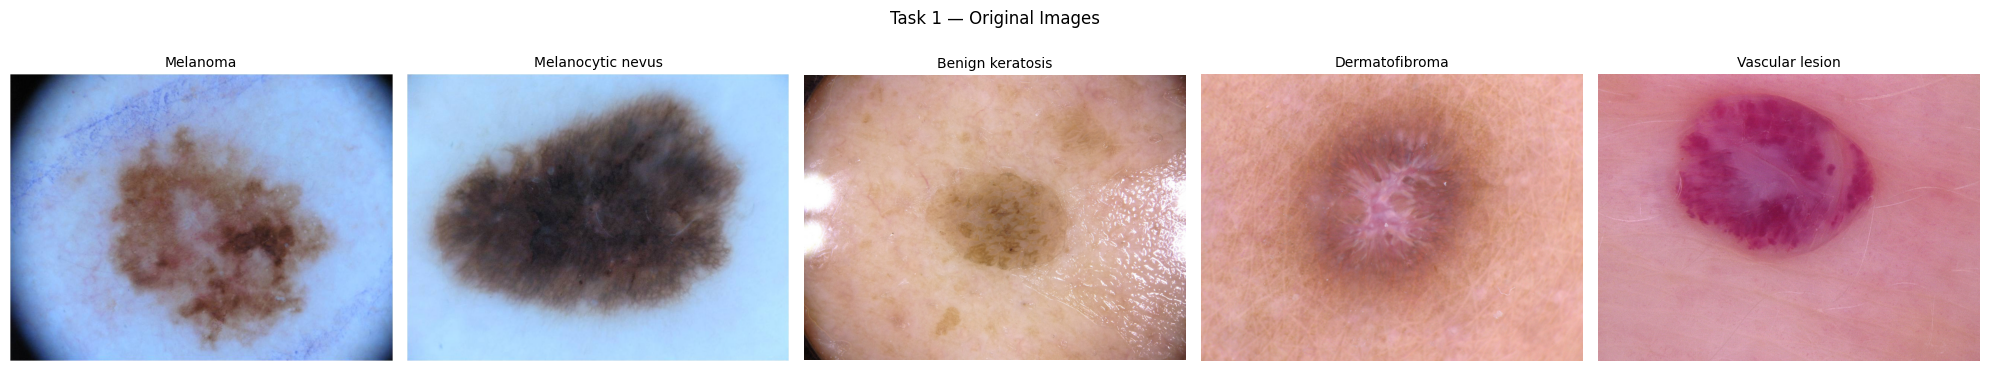

In [3]:
SELECTED_CLASSES = [
    "Melanoma",
    "Melanocytic nevus",
    "Benign keratosis",
    "Dermatofibroma",
    "Vascular lesion",
]

# Pick one representative image per class (first image found in train/<class>)
image_paths = []
for cls in SELECTED_CLASSES:
    folder = os.path.join(base_src, "train", cls)
    first_img = sorted(glob.glob(os.path.join(folder, "*")))[0]
    image_paths.append(first_img)

images_bgr = [cv2.imread(p) for p in image_paths]
images_rgb = [cv2.cvtColor(im, cv2.COLOR_BGR2RGB) for im in images_bgr]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, img, cls in zip(axes, images_rgb, SELECTED_CLASSES):
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis("off")
plt.suptitle("Task 1 — Original Images")
plt.tight_layout()
plt.savefig("task1_originals.png", dpi=150)
plt.show()

## Task 2 — Preprocess the Image

Convert to grayscale, then apply a Gaussian filter to reduce noise before edge detection.

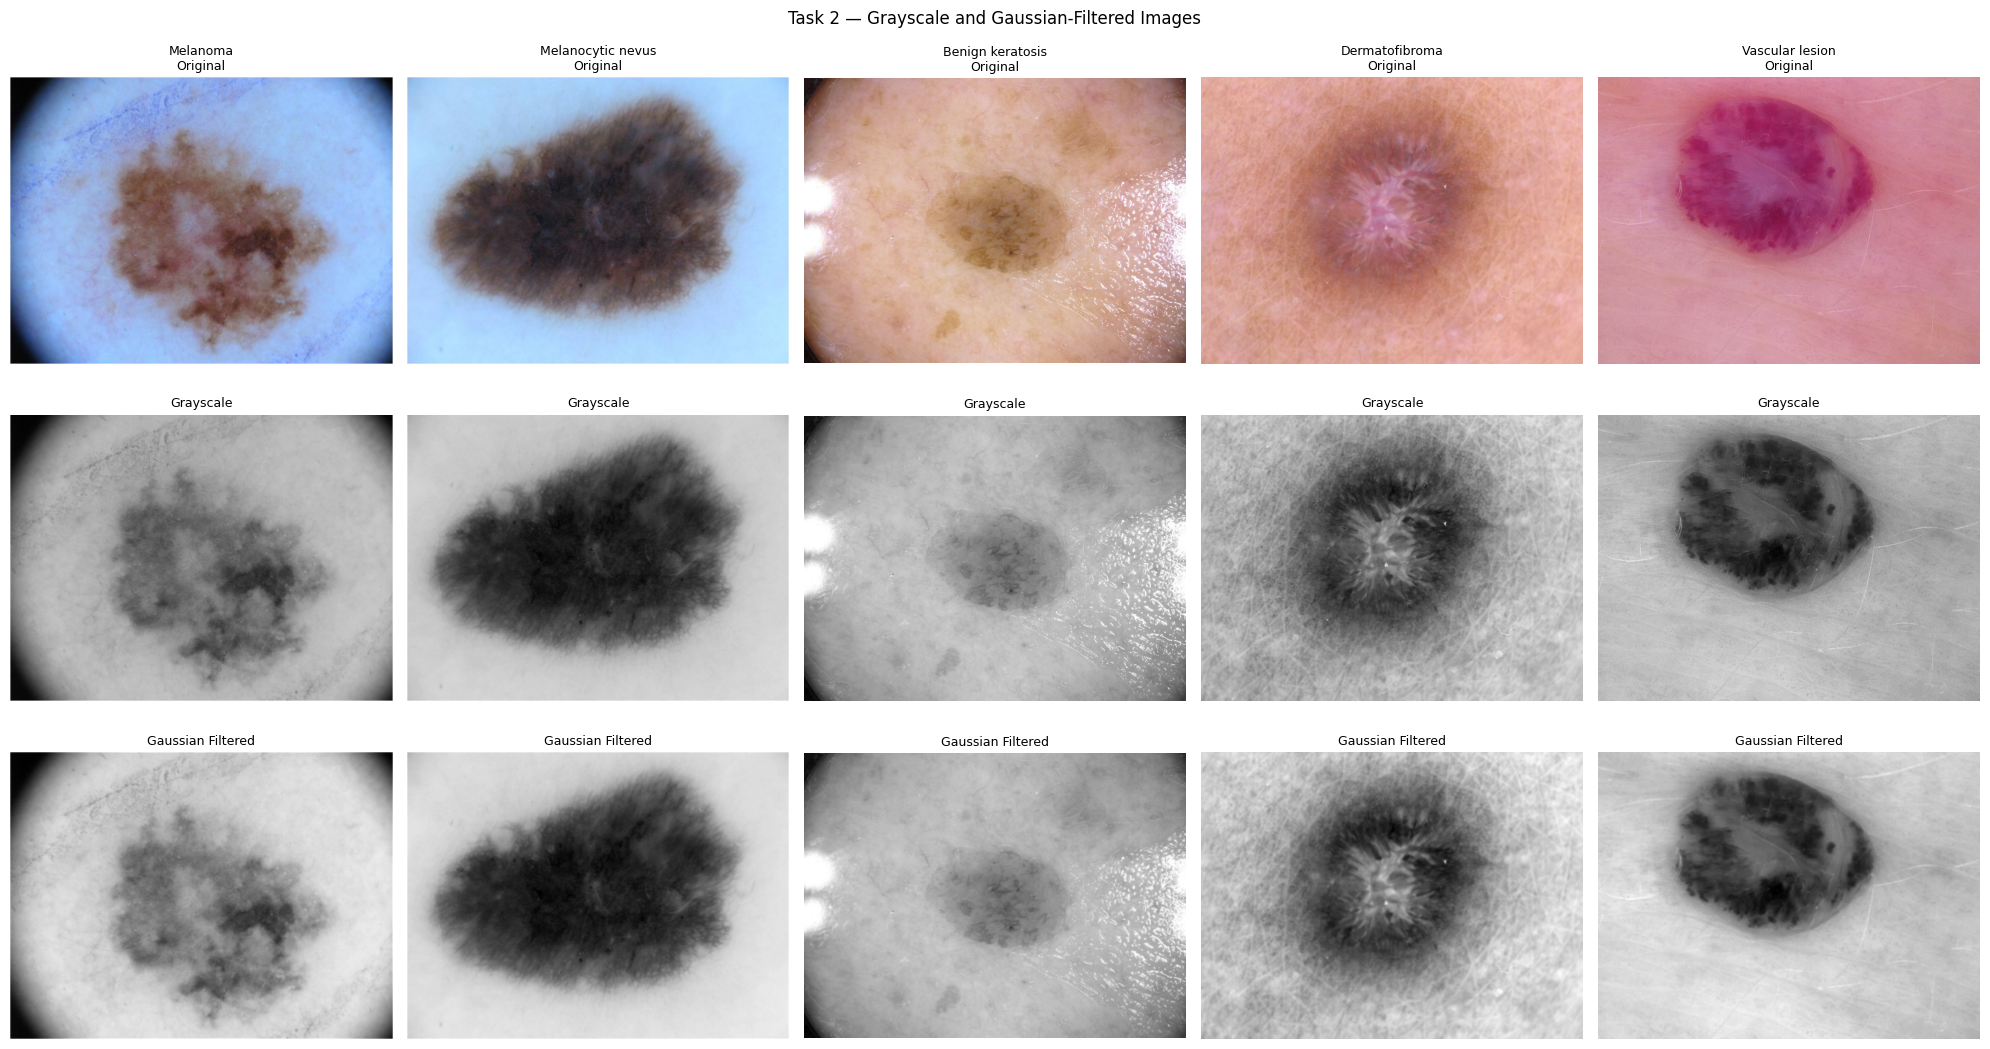

In [4]:
def to_gray(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

def gaussian_blur(gray, ksize=5, sigma=1.0):
    return cv2.GaussianBlur(gray, (ksize, ksize), sigma)

grays = [to_gray(im) for im in images_bgr]
blurred = [gaussian_blur(g) for g in grays]

fig, axes = plt.subplots(3, 5, figsize=(20, 11))
for i in range(5):
    axes[0, i].imshow(images_rgb[i]); axes[0, i].set_title(f"{SELECTED_CLASSES[i]}\nOriginal", fontsize=9)
    axes[1, i].imshow(grays[i], cmap="gray"); axes[1, i].set_title("Grayscale", fontsize=9)
    axes[2, i].imshow(blurred[i], cmap="gray"); axes[2, i].set_title("Gaussian Filtered", fontsize=9)
    for r in range(3):
        axes[r, i].axis("off")
plt.suptitle("Task 2 — Grayscale and Gaussian-Filtered Images")
plt.tight_layout()
plt.savefig("task2_preprocessed.png", dpi=150)
plt.show()

## Task 3 — Apply Canny Edge Detection

Three threshold settings: 50–100, 100–200, 150–250.

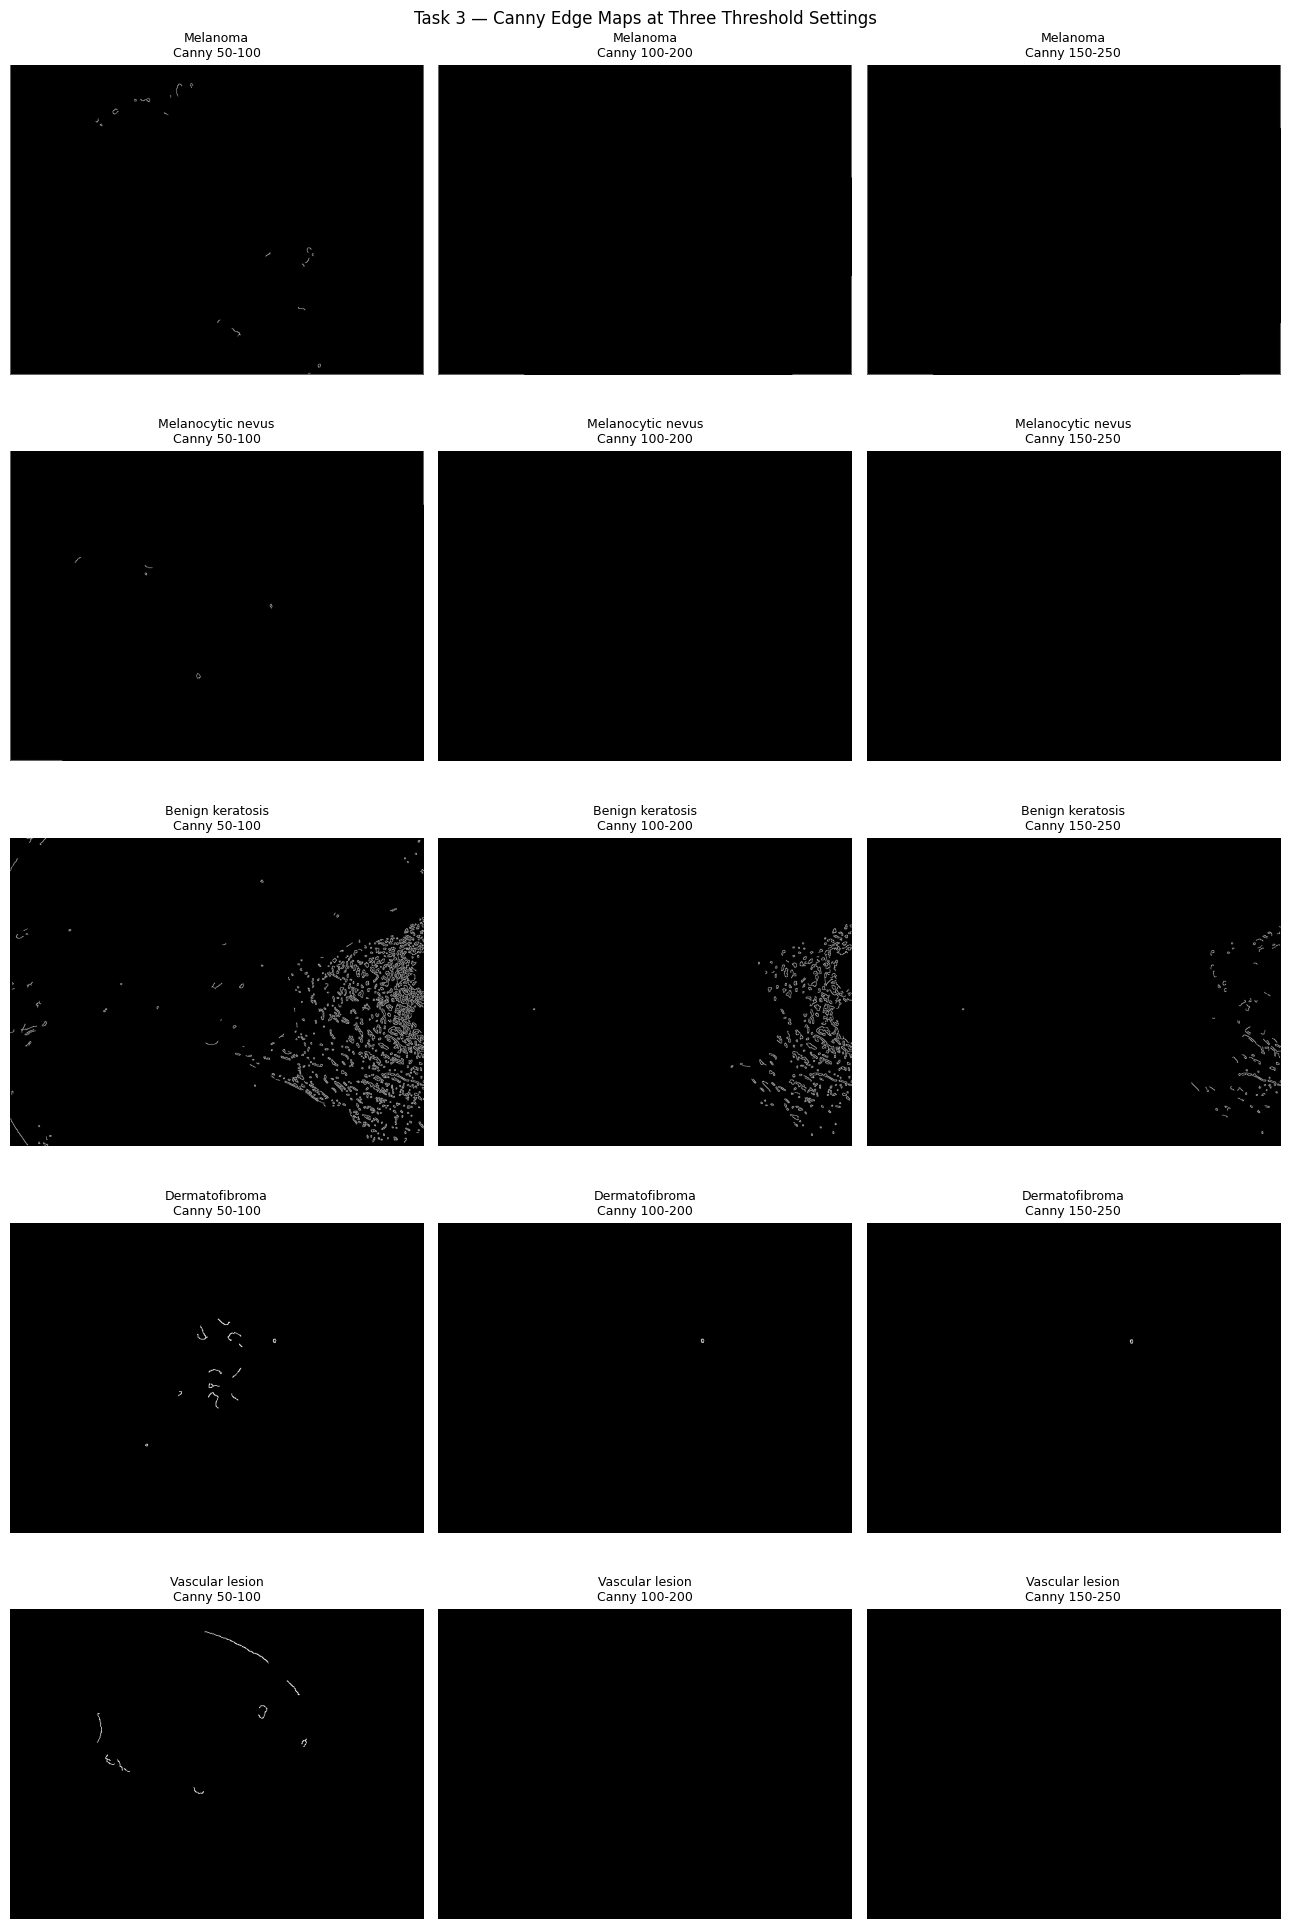

In [5]:
THRESHOLD_SETTINGS = [(50, 100), (100, 200), (150, 250)]

canny_results = []  # canny_results[img_idx][threshold_idx] = edge map
for b in blurred:
    row = [cv2.Canny(b, lo, hi) for (lo, hi) in THRESHOLD_SETTINGS]
    canny_results.append(row)

fig, axes = plt.subplots(5, 3, figsize=(13, 20))
for i in range(5):
    for j, (lo, hi) in enumerate(THRESHOLD_SETTINGS):
        axes[i, j].imshow(canny_results[i][j], cmap="gray")
        axes[i, j].set_title(f"{SELECTED_CLASSES[i]}\nCanny {lo}-{hi}", fontsize=9)
        axes[i, j].axis("off")
plt.suptitle("Task 3 — Canny Edge Maps at Three Threshold Settings")
plt.tight_layout()
plt.savefig("task3_canny_thresholds.png", dpi=150)
plt.show()

## Task 4 — Select the Best Result

We score each threshold's edge map by how well it forms a single, coherent, closed lesion
boundary: after a light morphological closing, we take the largest contour and measure its
**solidity** (contour area ÷ convex-hull area) and how much of the total edge-pixel mass it
captures. A clean, closed lesion boundary scores high on both; noisy or broken edges score low.
The threshold with the highest combined score is auto-selected per image — but you should still
visually confirm this against the printed edge maps above.

In [6]:
def score_edge_map(edge_map):
    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(edge_map, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0.0, closed, None
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)
    if area < 50:   # too small to be a real lesion boundary
        return 0.0, closed, None
    hull = cv2.convexHull(largest)
    hull_area = cv2.contourArea(hull) + 1e-6
    solidity = area / hull_area
    edge_pixels = np.count_nonzero(edge_map)
    capture_ratio = area / (edge_pixels + 1e-6)
    capture_ratio = min(capture_ratio, 1.0)
    score = 0.6 * solidity + 0.4 * capture_ratio
    return score, closed, largest

best_threshold_idx = []
best_contours = []
for i in range(5):
    scores = []
    contours_per_thresh = []
    for j in range(3):
        s, closed, cnt = score_edge_map(canny_results[i][j])
        scores.append(s)
        contours_per_thresh.append(cnt)
    best_j = int(np.argmax(scores))
    best_threshold_idx.append(best_j)
    best_contours.append(contours_per_thresh[best_j])
    lo, hi = THRESHOLD_SETTINGS[best_j]
    print(f"{SELECTED_CLASSES[i]:20s} -> best threshold {lo}-{hi}  (scores: "
          f"{[round(s,3) for s in scores]})")

Melanoma             -> best threshold 50-100  (scores: [1.0, 0.241, 0.281])
Melanocytic nevus    -> best threshold 50-100  (scores: [0.38, 0.0, 0.0])
Benign keratosis     -> best threshold 50-100  (scores: [0.735, 0.561, 0.265])
Dermatofibroma       -> best threshold 50-100  (scores: [0.0, 0.0, 0.0])
Vascular lesion      -> best threshold 50-100  (scores: [0.0, 0.0, 0.0])


## Task 5 — Detect the Lesion Boundary

Using the selected threshold's Canny edges, close gaps with morphology, extract the largest contour, and draw it on the original image.

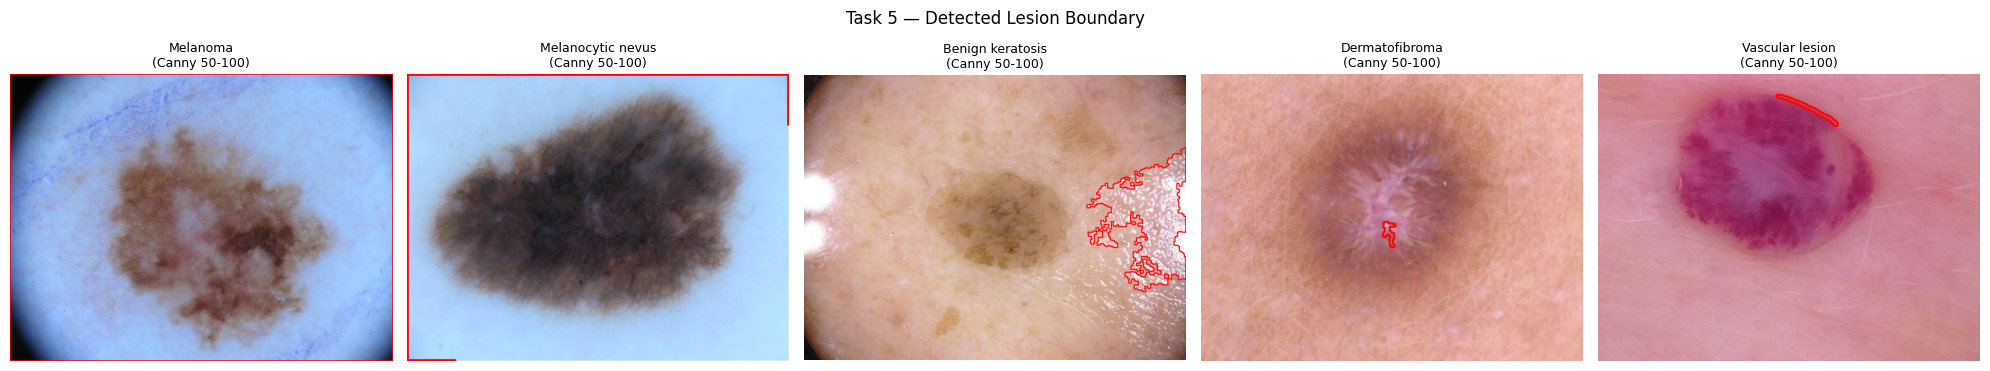

In [7]:
boundary_overlays = []
final_contours = []

for i in range(5):
    lo, hi = THRESHOLD_SETTINGS[best_threshold_idx[i]]
    edge_map = canny_results[i][best_threshold_idx[i]]

    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(edge_map, cv2.MORPH_CLOSE, kernel, iterations=2)
    closed = cv2.dilate(closed, kernel, iterations=1)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest = max(contours, key=cv2.contourArea)
    final_contours.append(largest)

    overlay = images_rgb[i].copy()
    cv2.drawContours(overlay, [largest], -1, (255, 0, 0), 2)
    boundary_overlays.append(overlay)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, overlay, cls, j in zip(axes, boundary_overlays, SELECTED_CLASSES, best_threshold_idx):
    lo, hi = THRESHOLD_SETTINGS[j]
    ax.imshow(overlay)
    ax.set_title(f"{cls}\n(Canny {lo}-{hi})", fontsize=9)
    ax.axis("off")
plt.suptitle("Task 5 — Detected Lesion Boundary")
plt.tight_layout()
plt.savefig("task5_boundaries.png", dpi=150)
plt.show()

## Task 6 — Calculate Lesion Area and Perimeter

In [8]:
areas = [cv2.contourArea(c) for c in final_contours]
perimeters = [cv2.arcLength(c, True) for c in final_contours]

task6_df = pd.DataFrame({
    "Image": SELECTED_CLASSES,
    "Best Filter": ["Gaussian"] * 5,
    "Edge Method": [f"Canny {THRESHOLD_SETTINGS[j][0]}-{THRESHOLD_SETTINGS[j][1]}" for j in best_threshold_idx],
    "Area (pixels)": [round(a, 1) for a in areas],
    "Perimeter (pixels)": [round(p, 1) for p in perimeters],
})
task6_df.to_csv("task6_area_perimeter_results.csv", index=False)
print("=== Required Results Table ===")
task6_df

=== Required Results Table ===


,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Melanoma,Gaussian,Canny 50-100,782086.0,3574.0
1,Melanocytic nevus,Gaussian,Canny 50-100,6133.5,4092.2
2,Benign keratosis,Gaussian,Canny 50-100,49424.5,3078.6
3,Dermatofibroma,Gaussian,Canny 50-100,393.0,133.9
4,Vascular lesion,Gaussian,Canny 50-100,594.5,237.9


## Required Visualization — Full Pipeline per Image

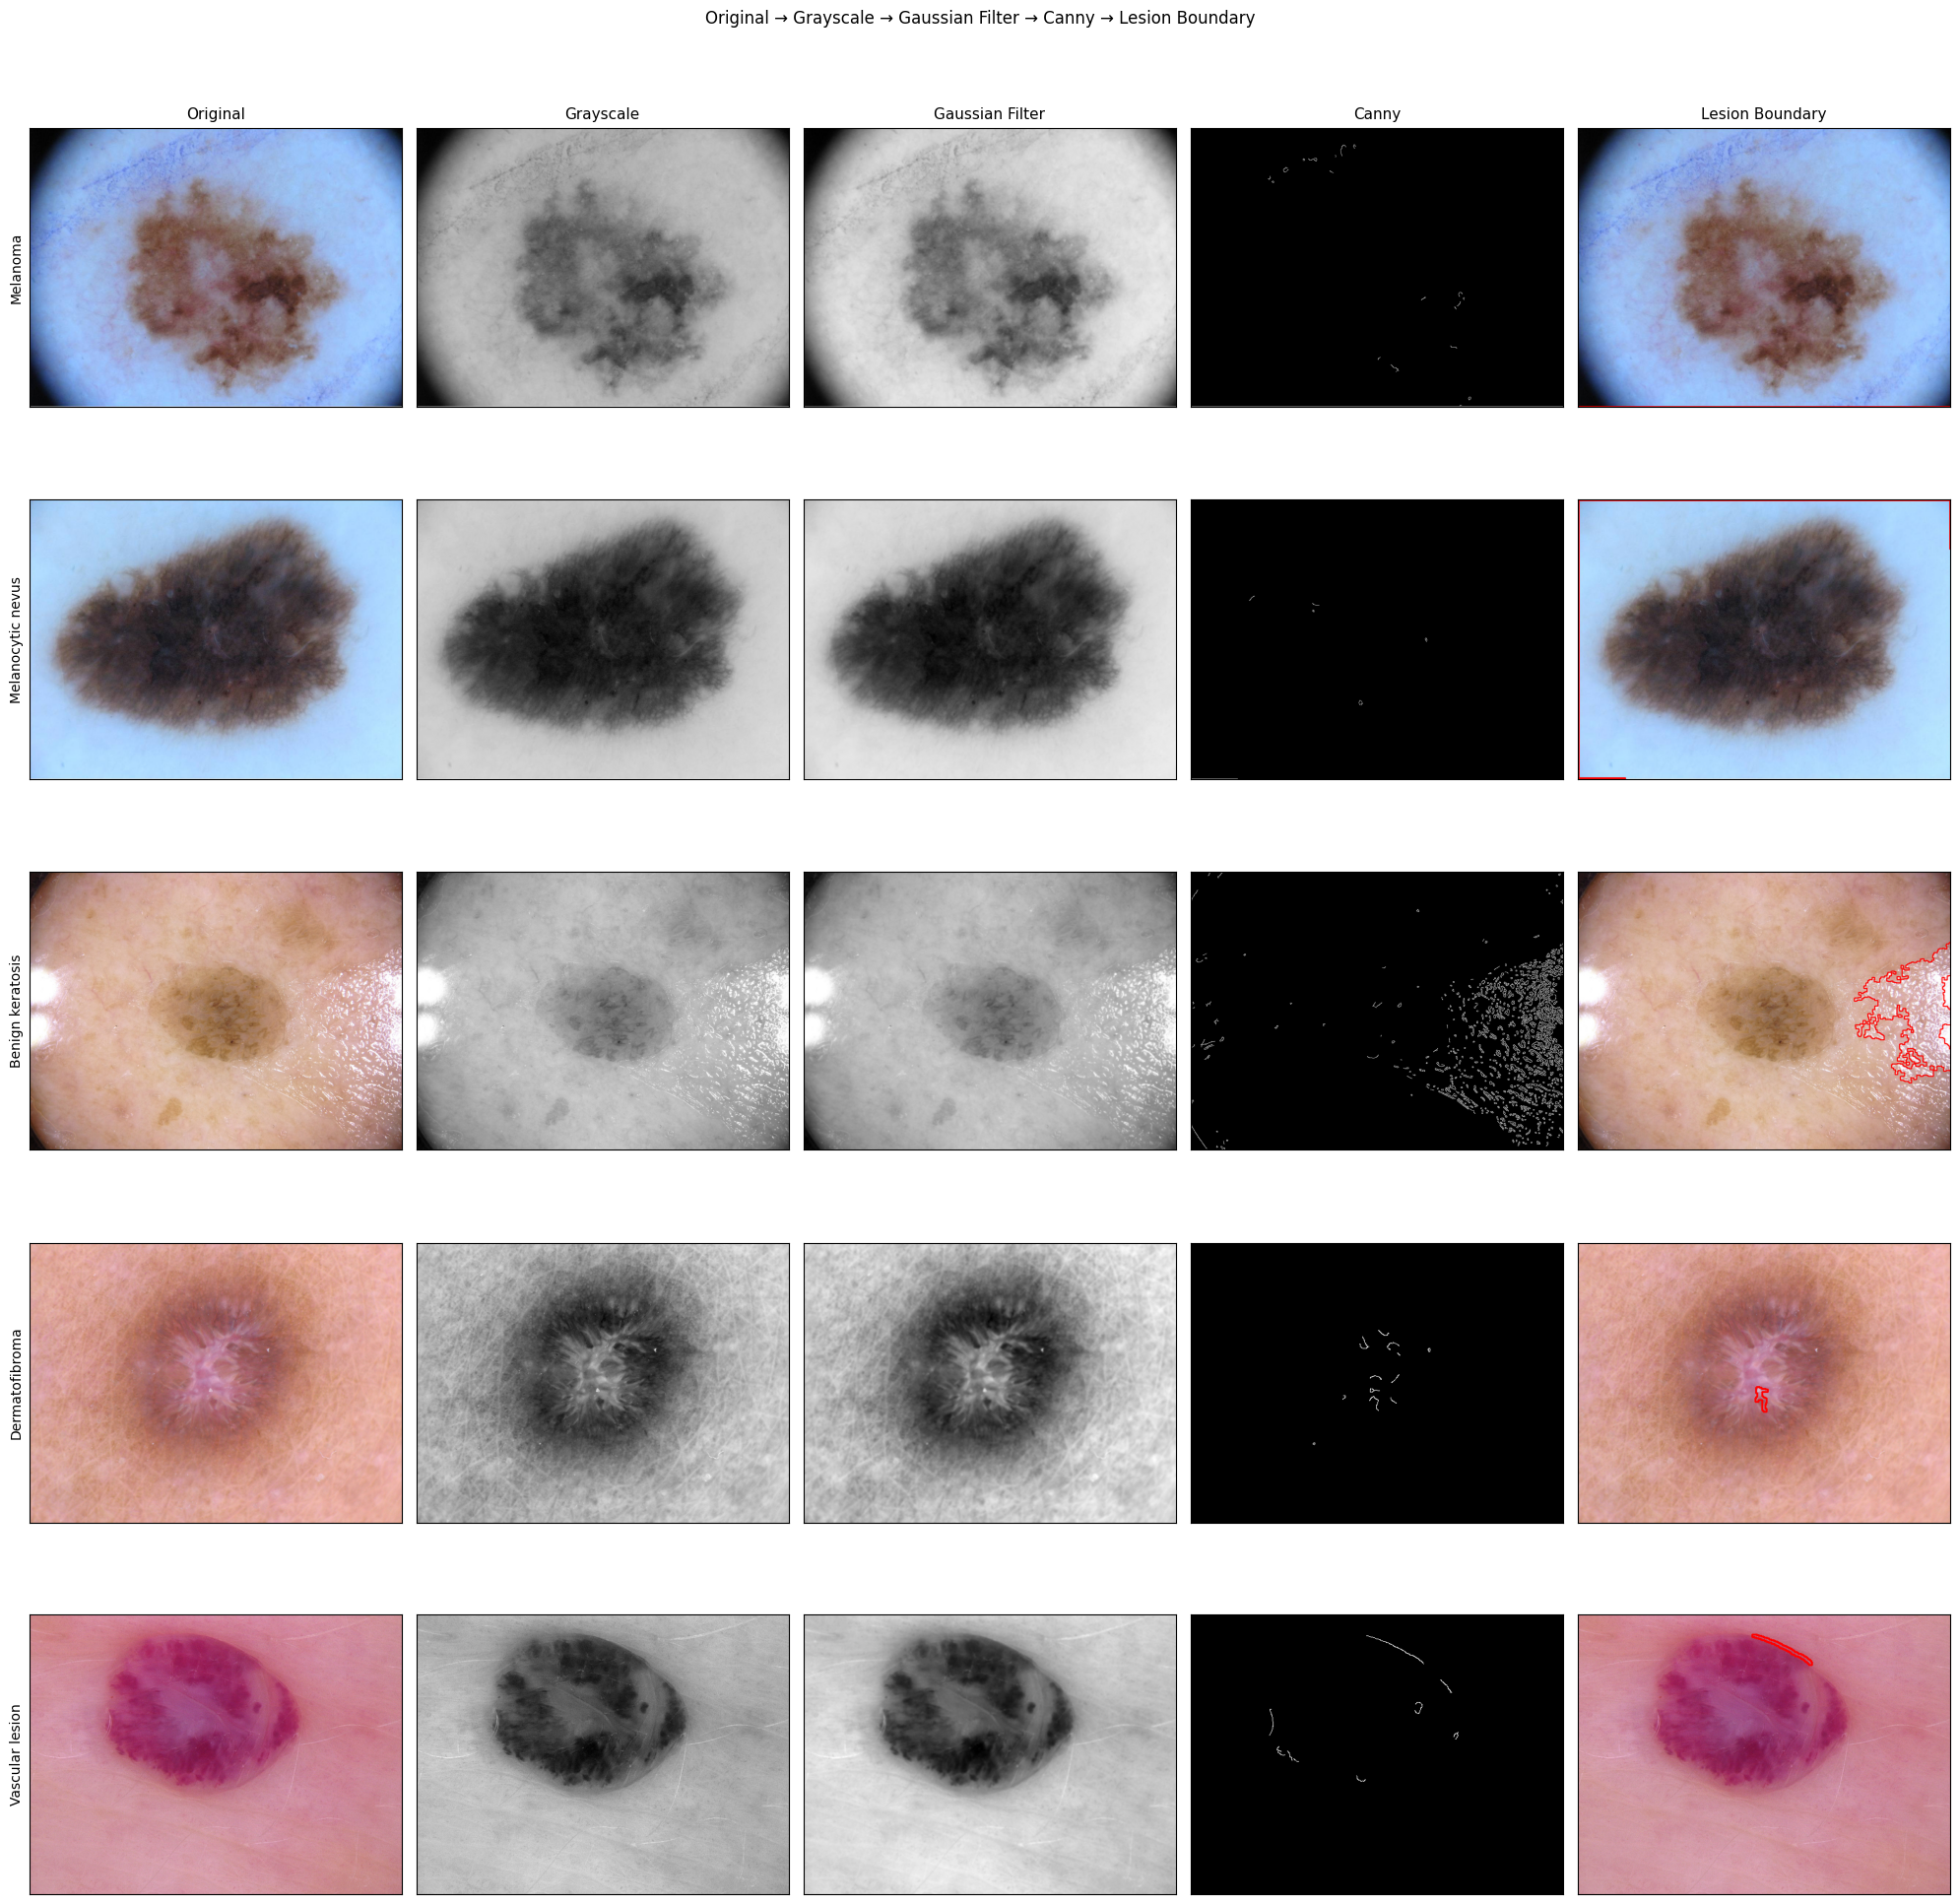

In [9]:
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
col_titles = ["Original", "Grayscale", "Gaussian Filter", "Canny", "Lesion Boundary"]
for i in range(5):
    j = best_threshold_idx[i]
    row_imgs = [images_rgb[i], grays[i], blurred[i], canny_results[i][j], boundary_overlays[i]]
    cmaps = [None, "gray", "gray", "gray", None]
    for c in range(5):
        axes[i, c].imshow(row_imgs[c], cmap=cmaps[c])
        if i == 0:
            axes[i, c].set_title(col_titles[c], fontsize=11)
        if c == 0:
            axes[i, c].set_ylabel(SELECTED_CLASSES[i], fontsize=10)
        axes[i, c].set_xticks([]); axes[i, c].set_yticks([])
plt.suptitle("Original → Grayscale → Gaussian Filter → Canny → Lesion Boundary", y=1.0)
plt.tight_layout()
plt.savefig("full_pipeline_grid.png", dpi=150, bbox_inches="tight")
plt.show()

## Final Comparison — Filter × Edge-Detector Combinations

We quantitatively score all 8 combinations (Original/Average/Gaussian/Median preprocessing ×
Sobel/Canny edge detection), averaged across the 5 images, then map the scores to qualitative
labels so the table isn't just a guess:

- **Noise Handling** — inverse of spurious small-contour count after edge detection (fewer stray
  fragments = better noise handling).
- **Edge Quality** — fraction of edge-pixel energy concentrated in the single largest connected
  contour (more concentrated = cleaner, less fragmented edges).
- **Boundary Detection** — solidity of the largest contour (area ÷ convex-hull area); closer to
  1.0 means a cleaner, more closed lesion outline.
- **Overall Performance** — average of the three scores above.

In [11]:
def apply_preprocess(gray, name):
    if name == "Original":
        return gray
    elif name == "Average":
        return cv2.blur(gray, (5, 5))
    elif name == "Gaussian":
        return cv2.GaussianBlur(gray, (5, 5), 1.0)
    elif name == "Median":
        return cv2.medianBlur(gray, 5)
    raise ValueError(name)

def sobel_edges(gray):
    sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    mag = np.uint8(255 * mag / (mag.max() + 1e-8))
    _, edge = cv2.threshold(mag, 50, 255, cv2.THRESH_BINARY)
    return edge

def canny_edges(gray):
    return cv2.Canny(gray, 100, 200)   # fixed mid-range threshold for a fair cross-method comparison

def analyze_edge_map(edge_map):
    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(edge_map, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    total_edge_px = np.count_nonzero(edge_map)
    if not contours or total_edge_px == 0:
        return 0.0, 0.0, 0.0
    areas_c = [cv2.contourArea(c) for c in contours]
    largest = contours[int(np.argmax(areas_c))]
    largest_area = max(areas_c)

    # noise handling: inverse of number of tiny spurious contours (relative to total)
    small_contours = sum(1 for a in areas_c if a < 0.05 * (largest_area + 1e-6))
    noise_score = 1.0 / (1.0 + small_contours)

    # edge quality: how much of the edge-pixel mass sits on the largest contour's perimeter region
    mask = np.zeros_like(edge_map)
    cv2.drawContours(mask, [largest], -1, 255, 2)
    overlap = np.count_nonzero(cv2.bitwise_and(edge_map, mask))
    edge_quality = overlap / (total_edge_px + 1e-6)
    edge_quality = min(edge_quality, 1.0)

    # boundary detection: solidity of the largest contour
    hull = cv2.convexHull(largest)
    hull_area = cv2.contourArea(hull) + 1e-6
    solidity = largest_area / hull_area

    return noise_score, edge_quality, solidity

def label_score(score):
    if score >= 0.75: return "Excellent"
    if score >= 0.55: return "Good"
    if score >= 0.35: return "Fair"
    return "Poor"

PREPROCESS_NAMES = ["Original", "Average", "Gaussian", "Median"]
EDGE_METHODS = ["Sobel", "Canny"]

comparison_rows = []
for pre_name in PREPROCESS_NAMES:
    for edge_name in EDGE_METHODS:
        noise_list, quality_list, solidity_list = [], [], []
        for g in grays:
            processed = apply_preprocess(g, pre_name)
            edge_map = sobel_edges(processed) if edge_name == "Sobel" else canny_edges(processed)
            n, q, s = analyze_edge_map(edge_map)
            noise_list.append(n); quality_list.append(q); solidity_list.append(s)

        noise_avg = np.mean(noise_list)
        quality_avg = np.mean(quality_list)
        solidity_avg = np.mean(solidity_list)
        overall_avg = np.mean([noise_avg, quality_avg, solidity_avg])

        comparison_rows.append({
            "Method": f"{pre_name} + {edge_name}",
            "Noise Handling": label_score(noise_avg),
            "Edge Quality": label_score(quality_avg),
            "Boundary Detection": label_score(solidity_avg),
            "Overall Performance": label_score(overall_avg),
        })

final_comparison_df = pd.DataFrame(comparison_rows)
final_comparison_df.to_csv("final_comparison_table.csv", index=False)
print("=== Final Comparison Table ===")
final_comparison_df

=== Final Comparison Table ===


,Method,Noise Handling,Edge Quality,Boundary Detection,Overall Performance
0,Original + Sobel,Fair,Fair,Good,Fair
1,Original + Canny,Good,Good,Excellent,Good
2,Average + Sobel,Poor,Poor,Fair,Poor
3,Average + Canny,Fair,Poor,Poor,Poor
4,Gaussian + Sobel,Fair,Poor,Good,Fair
5,Gaussian + Canny,Fair,Poor,Poor,Poor
6,Median + Sobel,Fair,Fair,Good,Fair
7,Median + Canny,Good,Good,Good,Good
